# 05 — LLM Validation Pipeline

Reliability and consistency testing for narrative classification using Llama 3 (Ollama). This notebook implements the validation framework proposed by Törnberg (2024), focusing on prompt stability and agreement with human labels.

In [12]:
import pandas as pd
import numpy as np
import ollama
import json
import time
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('aletheia_filtered.csv')
embeddings = np.load('embeddings_filtered.npy')
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
device = model.device

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

### Data Retrieval

In [13]:
queries = [
    "Vacinas causam doenças autoimunes",
    "Vacinas contêm microchips ou substâncias ocultas",
    "Governos escondem efeitos colaterais das vacinas",
    "Imunidade natural é superior à vacinal",
    "Vacinas foram desenvolvidas rápido demais e não são seguras"
]

corpus_t = torch.from_numpy(embeddings).to(device)

search_res = {}
for q in queries:
    q_emb = model.encode(q, convert_to_tensor=True)
    sims = util.cos_sim(q_emb, corpus_t)[0]
    top = torch.topk(sims, k=20)
    search_res[q] = {
        'idx': top.indices.tolist(),
        'scores': top.values.tolist()
    }

### Classification Prompts

In [14]:
JSON_INSTR = "Retorne APENAS um objeto JSON: {{'classification': 'SUPPORTS/NEUTRAL/REFUTES', 'confidence': 0.0, 'reasoning': '...'}}"

PROMPT_TEMPLATES = {
    'a': (
        "Analise se esta mensagem do Telegram apoia a narrativa: '{narrative}'.\n\n"
        "MENSAGEM: {text}\n\n"
        "Rótulos: SUPPORTS (promove a ideia), NEUTRAL (apenas menciona o tema), REFUTES (desmente a ideia).\n"
        f"{JSON_INSTR}"
    ),
    'b': (
        "O texto a seguir promove a narrativa de desinformação '{narrative}'?\n\n"
        "TEXTO: {text}\n\n"
        "Opções: SUPPORTS, NEUTRAL, REFUTES.\n"
        f"{JSON_INSTR}"
    ),
    'c': (
        "Você é um pesquisador especialista. Classifique a mensagem quanto ao tema: '{narrative}'\n\n"
        "CONTEÚDO: {text}\n\n"
        f"{JSON_INSTR}"
    )
}

def ask_llama(text, narrative, version='a'):
    prompt = PROMPT_TEMPLATES[version].format(text=text, narrative=narrative)
    try:
        r = ollama.chat(model='llama3', messages=[{'role': 'user', 'content': prompt}], format='json')
        return json.loads(r['message']['content'])
    except Exception:
        return {'classification': 'ERROR'}

### 1. Face Validity

In [15]:
v_tests = {
    "Vacinas contêm microchips ou substâncias ocultas": [
        ("URGENTE!! Vazam documentos provando que a tecnologia de grafeno nas vacinas é real e serve para rastreio populacional. Compartilhem!", "SUPPORTS"),
        ("O governo anunciou a chegada de mais 5 milhões de doses da vacina para reforço da imunização.", "NEUTRAL"),
        ("É fake news total a história do 5G e grafeno. Cientistas explicam que esses componentes sequer cabem em uma seringa comum.", "REFUTES")
    ]
}

for n, tests in v_tests.items():
    for txt, exp in tests:
        res = ask_llama(txt, n)
        label = res.get('classification', 'NONE')
        print(f"Exp: {exp} | Got: {label} | Text: {txt[:60]}...")
        time.sleep(0.3)

Exp: SUPPORTS | Got: SUPPORTS | Text: URGENTE!! Vazam documentos provando que a tecnologia de graf...
Exp: NEUTRAL | Got: NEUTRAL | Text: O governo anunciou a chegada de mais 5 milhões de doses da v...
Exp: REFUTES | Got: REFUTES | Text: É fake news total a história do 5G e grafeno. Cientistas exp...


### 2. Prompt Brittleness

In [16]:
target_n = queries[1]
indices = search_res[target_n]['idx'][:10]
brit_results = []

for i in indices:
    txt = str(df.iloc[i]['text_content'])[:500]
    results = {'idx': i}
    for v in ['a', 'b', 'c']:
        res = ask_llama(txt, target_n, version=v)
        results[f'prompt_{v}'] = res.get('classification', 'ERROR')
    brit_results.append(results)
    time.sleep(0.2)

b_df = pd.DataFrame(brit_results)
agreement = b_df.apply(lambda x: x['prompt_a'] == x['prompt_b'] == x['prompt_c'], axis=1).mean()
print(f"Prompt agreement rate: {agreement:.1%}")
b_df

Prompt agreement rate: 10.0%


,idx,prompt_a,prompt_b,prompt_c
0,10290,SUPPORTS,REFUTES,REFUTES
1,13981,SUPPORTS,REFUTES,SUPPORTS
2,11896,SUPPORTS,SUPPORTS,REFUTES
3,3357,SUPPORTS,SUPPORTS,REFUTES
4,4769,SUPPORTS,REFUTES,NEUTRAL
5,6192,SUPPORTS,REFUTES,REFUTES
6,8210,SUPPORTS,SUPPORTS,REFUTES
7,730,SUPPORTS,SUPPORTS,REFUTES
8,16538,SUPPORTS,SUPPORTS,SUPPORTS
9,1169,SUPPORTS,REFUTES,SUPPORTS


### 3. Batch Narrative Validation

In [17]:
final_dataset = []
for n in queries:
    ids = search_res[n]['idx']
    scores = search_res[n]['scores']
    print(f"Validating narrative: {n[:40]}...")
    
    for i, s in zip(ids, scores):
        txt = str(df.iloc[i]['text_content'])[:500]
        res = ask_llama(txt, n)
        res.update({'narrative': n, 'msg_idx': i, 'cosine_score': s})
        final_dataset.append(res)
        time.sleep(0.2)

v_df = pd.DataFrame(final_dataset)
v_df.to_csv('validation_results.csv', index=False)
v_df.groupby(['narrative', 'classification']).size().unstack(fill_value=0)

Validating narrative: Vacinas causam doenças autoimunes...
Validating narrative: Vacinas contêm microchips ou substâncias...
Validating narrative: Governos escondem efeitos colaterais das...
Validating narrative: Imunidade natural é superior à vacinal...
Validating narrative: Vacinas foram desenvolvidas rápido demai...


classification,NEUTRAL,REFUTES,SUPPORTS
narrative,,,
Governos escondem efeitos colaterais das vacinas,0,1,19
Imunidade natural é superior à vacinal,0,0,20
Vacinas causam doenças autoimunes,1,0,19
Vacinas contêm microchips ou substâncias ocultas,0,0,20
Vacinas foram desenvolvidas rápido demais e não são seguras,1,0,19


### 4. Human Validation Sample
Generating a sample of 100 messages for robust manual label verification.

In [18]:
import os
if not os.path.exists('human_check.csv'):
    sample = v_df.sample(100, random_state=42).copy()
    sample['human_label'] = ''
    sample[['msg_idx', 'narrative', 'classification', 'human_label']].to_csv('human_check.csv', index=False)
    print("Sample of 100 messages exported to 'human_check.csv'.")
else:
    print("'human_check.csv' already exists. Skipping export to avoid overwriting your manual labels.")

'human_check.csv' already exists. Skipping export to avoid overwriting your manual labels.


### 5. Metrics calculation

LLM performance vs Human gold-standard (N=100):

              precision    recall  f1-score   support

     NEUTRAL       1.00      0.06      0.11        33
     REFUTES       0.00      0.00      0.00         1
    SUPPORTS       0.67      0.97      0.80        66

    accuracy                           0.66       100
   macro avg       0.56      0.34      0.30       100
weighted avg       0.77      0.66      0.56       100



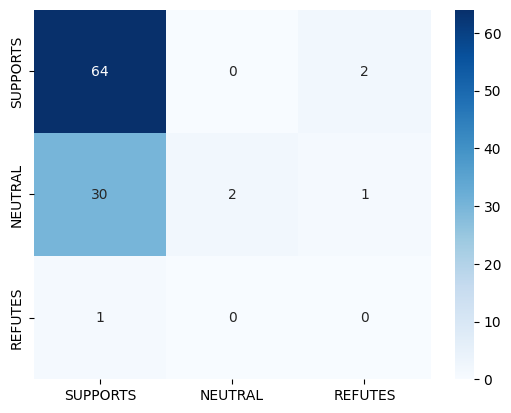

In [19]:
try:
    gold = pd.read_csv('human_check.csv')
    gold = gold.dropna(subset=['human_label'])
    gold['human_label'] = gold['human_label'].astype(str)
    y_true = gold['human_label'].str.upper().str.strip()
    y_pred = gold['classification'].str.upper().str.strip()
    
    if not y_true.empty:
        print(f"LLM performance vs Human gold-standard (N={len(y_true)}):\n")
        print(classification_report(y_true, y_pred))
        
        cm = confusion_matrix(y_true, y_pred, labels=['SUPPORTS', 'NEUTRAL', 'REFUTES'])
        sns.heatmap(cm, annot=True, cmap='Blues', 
                    xticklabels=['SUPPORTS', 'NEUTRAL', 'REFUTES'], 
                    yticklabels=['SUPPORTS', 'NEUTRAL', 'REFUTES'])
        plt.show()
    else:
        print("File found but 'human_label' column is empty.")
except Exception:
    print("Human validation data ('human_check.csv') not ready.")

---
## 6. Model Comparison

The llama3 8B baseline showed a strong SUPPORTS bias (95%) and very low agreement with human labels (Cohen's kappa ~0.07). Let's check if using bigger/newer models helps with that.

In [20]:
def classify_with_model(text, narrative, model_name, version='a'):
    prompt = PROMPT_TEMPLATES[version].format(text=text, narrative=narrative)
    try:
        r = ollama.chat(
            model=model_name,
            messages=[{'role': 'user', 'content': prompt}],
            format='json'
        )
        parsed = json.loads(r['message']['content'])
        label = parsed.get('classification', 'ERROR').upper().strip()
        if label not in ('SUPPORTS', 'NEUTRAL', 'REFUTES'):
            label = 'ERROR'
        return label
    except Exception as e:
        print(f'  [ERROR] {model_name}: {e}')
        return 'ERROR'

In [21]:
gold = pd.read_csv('human_check.csv')
gold = gold.dropna(subset=['human_label'])
gold['human_label'] = gold['human_label'].astype(str)
gold = gold[gold['human_label'].str.strip() != '']
gold['human_label'] = gold['human_label'].str.upper().str.strip()
gold['llama3_label'] = gold['classification'].str.upper().str.strip()

print(f'Gold standard samples: {len(gold)}')
print(f'Human label distribution:\n{gold["human_label"].value_counts().to_string()}')

Gold standard samples: 100
Human label distribution:
human_label
SUPPORTS    66
NEUTRAL     33
REFUTES      1


In [22]:
MODELS_TO_TEST = ['llama3.1:8b', 'gemma2:27b']

for model_name in MODELS_TO_TEST:
    col = model_name.replace(':', '_').replace('.', '_')
    print(f'\n{"="*60}')
    print(f'Classifying with {model_name} ({len(gold)} samples)...')
    print(f'{"="*60}')
    
    labels = []
    for i, (_, row) in enumerate(gold.iterrows()):
        txt = str(row['text_content'])[:500]
        narrative = row['narrative']
        label = classify_with_model(txt, narrative, model_name)
        labels.append(label)
        if (i + 1) % 10 == 0:
            print(f'  [{i+1}/{len(gold)}] done')
        time.sleep(0.3)
    
    gold[col] = labels
    print(f'\n{model_name} distribution:')
    print(pd.Series(labels).value_counts().to_string())


Classifying with llama3.1:8b (100 samples)...
  [10/100] done
  [20/100] done
  [30/100] done
  [40/100] done
  [50/100] done
  [60/100] done
  [70/100] done
  [80/100] done
  [90/100] done
  [100/100] done

llama3.1:8b distribution:
SUPPORTS    93
NEUTRAL      5
REFUTES      2

Classifying with gemma2:27b (100 samples)...
  [10/100] done
  [20/100] done
  [30/100] done
  [40/100] done
  [50/100] done
  [60/100] done
  [70/100] done
  [80/100] done
  [90/100] done
  [100/100] done

gemma2:27b distribution:
SUPPORTS    95
NEUTRAL      5


In [23]:
gold.to_csv('model_comparison_results.csv', index=False)
print('Saved to model_comparison_results.csv')

Saved to model_comparison_results.csv


### 6.1 Comparative Metrics

In [24]:
from sklearn.metrics import cohen_kappa_score, accuracy_score, f1_score

y_true = gold['human_label']
target_labels = ['SUPPORTS', 'NEUTRAL', 'REFUTES']

model_cols = {
    'llama3 (8B)': 'llama3_label',
    'llama3.1 (8B)': 'llama3_1_8b',
    'gemma2 (27B)': 'gemma2_27b',
}

summary_rows = []
for name, col in model_cols.items():
    if col not in gold.columns:
        continue
    y_pred = gold[col]
    mask = y_pred.isin(target_labels)  # skip ERRORs
    yt, yp = y_true[mask], y_pred[mask]
    
    acc = accuracy_score(yt, yp)
    kappa = cohen_kappa_score(yt, yp)
    f1_macro = f1_score(yt, yp, labels=target_labels, average='macro', zero_division=0)
    f1_weighted = f1_score(yt, yp, labels=target_labels, average='weighted', zero_division=0)
    
    dist = yp.value_counts()
    supports_pct = dist.get('SUPPORTS', 0) / len(yp) * 100
    neutral_pct = dist.get('NEUTRAL', 0) / len(yp) * 100
    refutes_pct = dist.get('REFUTES', 0) / len(yp) * 100
    errors = (~mask).sum()
    
    summary_rows.append({
        'Model': name,
        'N': len(yp),
        'Accuracy': f'{acc:.1%}',
        'Cohen kappa': f'{kappa:.3f}',
        'F1 (macro)': f'{f1_macro:.3f}',
        'F1 (weighted)': f'{f1_weighted:.3f}',
        '% SUPPORTS': f'{supports_pct:.0f}%',
        '% NEUTRAL': f'{neutral_pct:.0f}%',
        '% REFUTES': f'{refutes_pct:.0f}%',
        'Errors': errors
    })

summary_df = pd.DataFrame(summary_rows)
print('Model Comparison Summary')
print('=' * 90)
print(summary_df.to_string(index=False))

Model Comparison Summary
        Model   N Accuracy Cohen kappa F1 (macro) F1 (weighted) % SUPPORTS % NEUTRAL % REFUTES  Errors
  llama3 (8B) 100    66.0%       0.071      0.303         0.562        95%        2%        3%       0
llama3.1 (8B) 100    66.0%       0.080      0.317         0.575        93%        5%        2%       0
 gemma2 (27B) 100    68.0%       0.102      0.322         0.585        95%        5%        0%       0


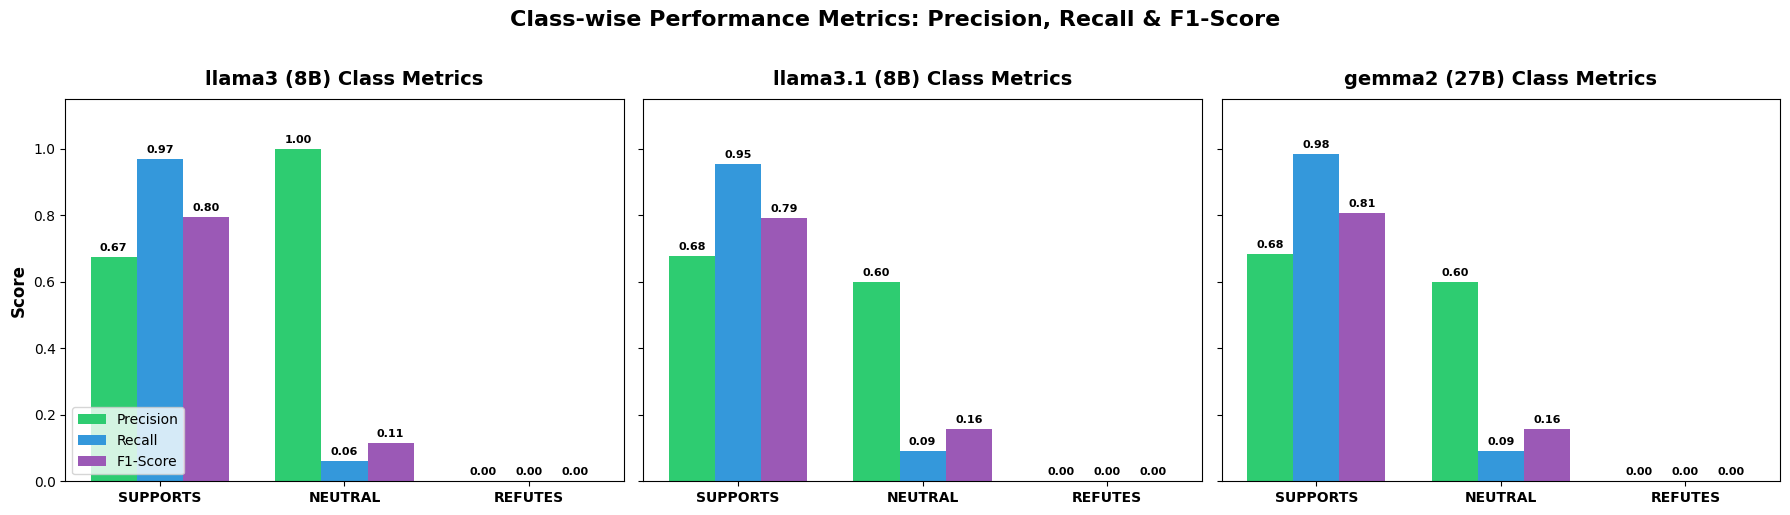

In [25]:
from sklearn.metrics import precision_recall_fscore_support

n_models = sum(1 for col in model_cols.values() if col in gold.columns)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

colors = ['#2ecc71', '#3498db', '#9b59b6']  # Green, Blue, Purple
idx = 0

for name, col in model_cols.items():
    if col not in gold.columns:
        continue
    y_pred = gold[col]
    mask = y_pred.isin(target_labels)
    yt, yp = y_true[mask], y_pred[mask]
    
    p, r, f, _ = precision_recall_fscore_support(yt, yp, labels=target_labels, zero_division=0)
    
    ax = axes[idx]
    x = np.arange(len(target_labels))
    width = 0.25
    
    rects1 = ax.bar(x - width, p, width, label='Precision', color=colors[0])
    rects2 = ax.bar(x, r, width, label='Recall', color=colors[1])
    rects3 = ax.bar(x + width, f, width, label='F1-Score', color=colors[2])
    
    ax.set_title(f'{name} Class Metrics', fontsize=14, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(target_labels, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.15)
    
    if idx == 0:
        ax.set_ylabel('Score', fontsize=12, fontweight='bold')
        ax.legend(loc='lower left', frameon=True)
        
    for rects in [rects1, rects2, rects3]:
        for rect in rects:
            h = rect.get_height()
            ax.annotate(f'{h:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, h),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, fontweight='bold')
    idx += 1

plt.suptitle('Class-wise Performance Metrics: Precision, Recall & F1-Score', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/model_comparison_metrics_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

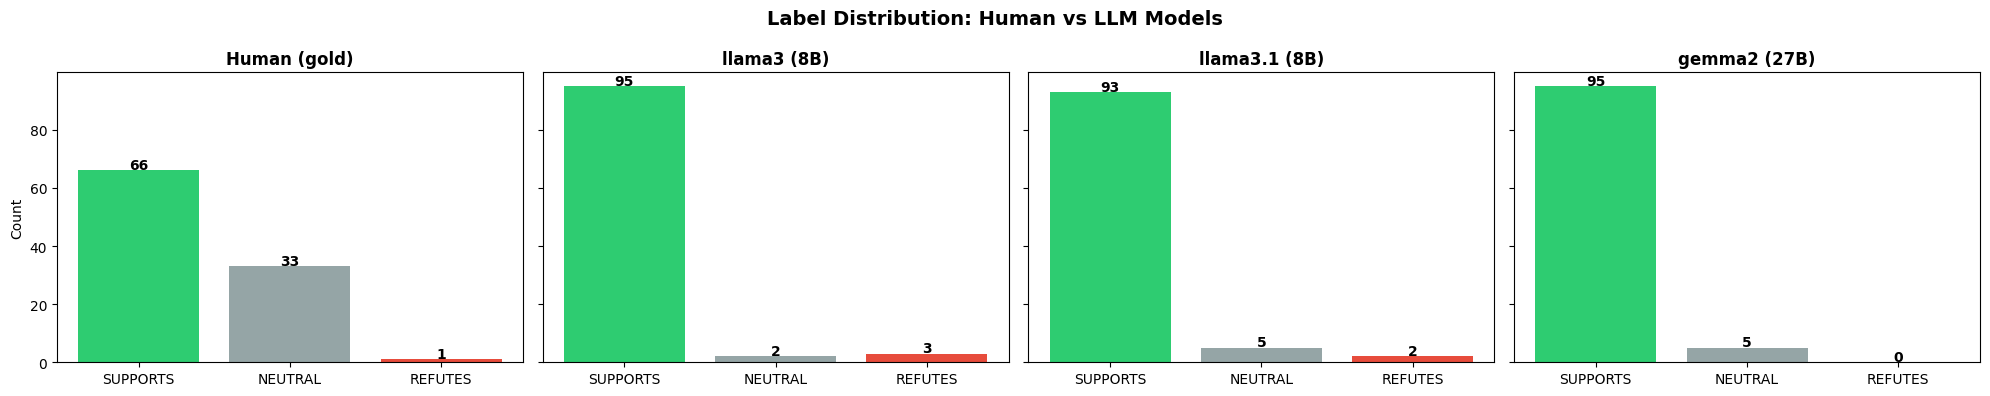

In [26]:
import os
os.makedirs('figures', exist_ok=True)

n_plots = 1 + sum(1 for col in model_cols.values() if col in gold.columns)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4), sharey=True)

human_dist = y_true.value_counts().reindex(target_labels, fill_value=0)
axes[0].bar(target_labels, human_dist.values, color=['#2ecc71', '#95a5a6', '#e74c3c'])
axes[0].set_title('Human (gold)', fontweight='bold')
axes[0].set_ylabel('Count')
for j, v in enumerate(human_dist.values):
    axes[0].text(j, v + 0.5, str(v), ha='center', fontweight='bold')

idx = 1
for name, col in model_cols.items():
    if col not in gold.columns:
        continue
    ax = axes[idx]
    dist = gold[col].value_counts().reindex(target_labels, fill_value=0)
    ax.bar(target_labels, dist.values, color=['#2ecc71', '#95a5a6', '#e74c3c'])
    ax.set_title(name, fontweight='bold')
    for j, v in enumerate(dist.values):
        ax.text(j, v + 0.5, str(v), ha='center', fontweight='bold')
    idx += 1

plt.suptitle('Label Distribution: Human vs LLM Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/model_comparison_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

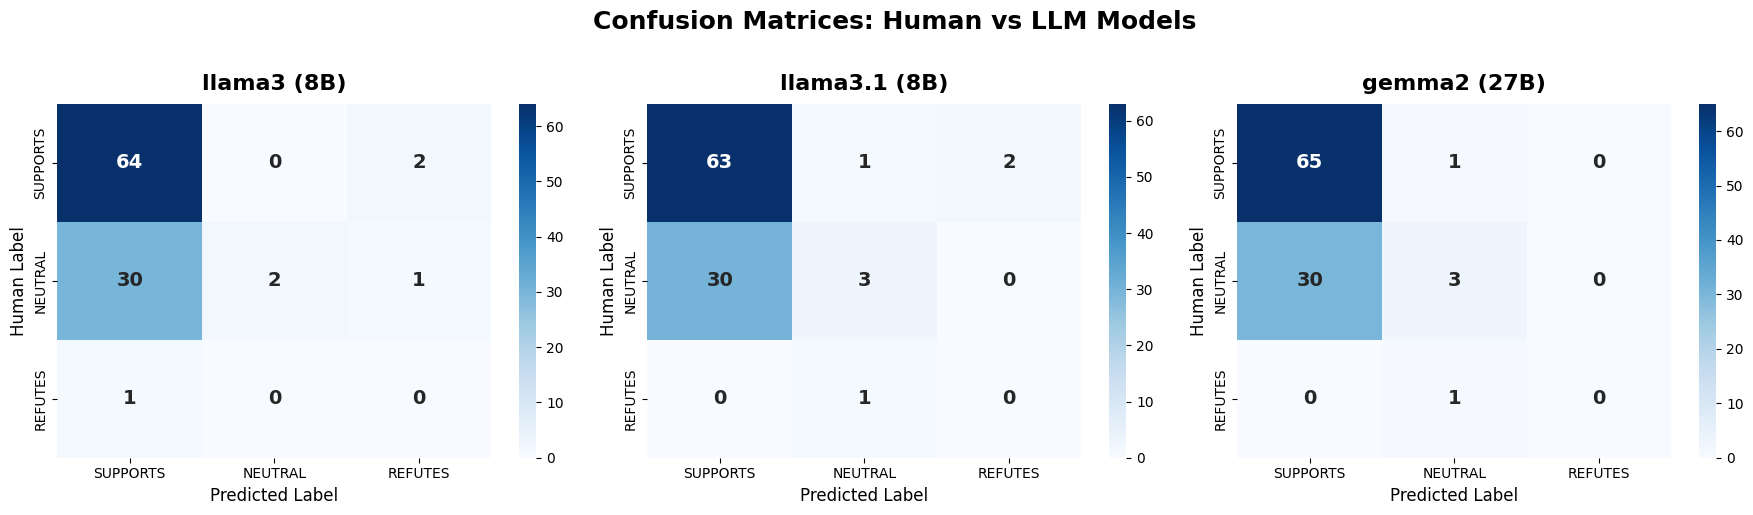

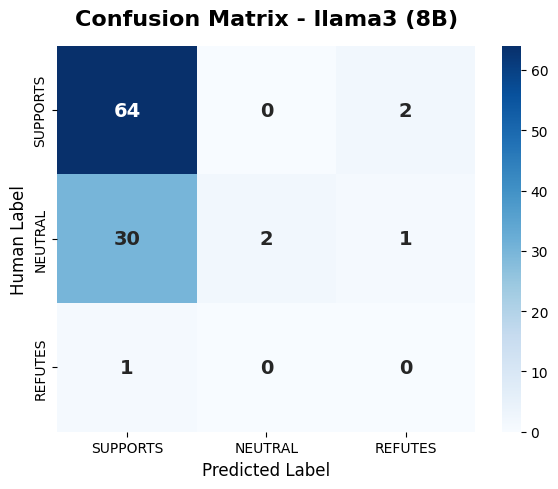

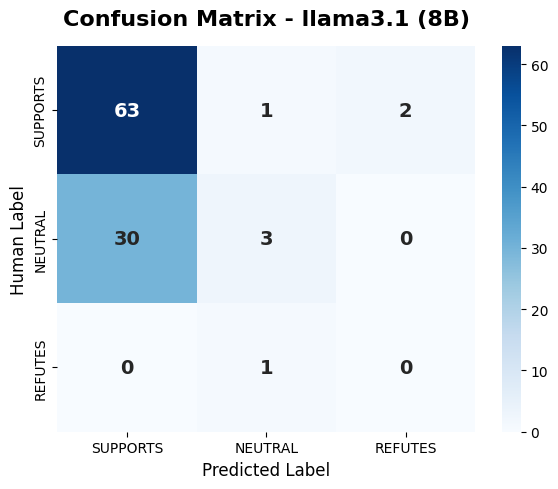

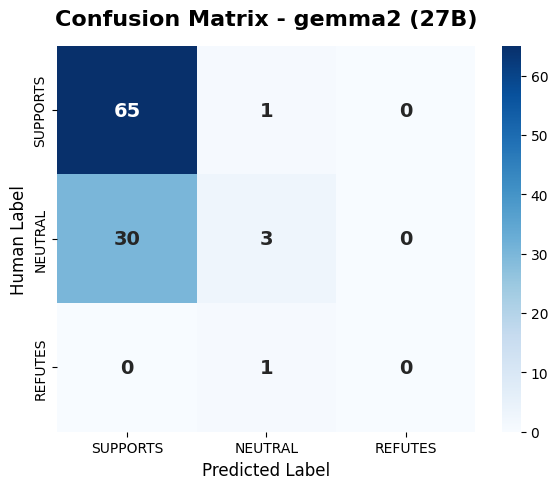

In [27]:
n_models = sum(1 for col in model_cols.values() if col in gold.columns)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

idx = 0
for name, col in model_cols.items():
    if col not in gold.columns:
        continue
    y_pred = gold[col]
    mask = y_pred.isin(target_labels)
    yt, yp = y_true[mask], y_pred[mask]
    
    cm = confusion_matrix(yt, yp, labels=target_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=target_labels, yticklabels=target_labels,
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[idx].set_title(f'{name}', fontsize=16, fontweight='bold', pad=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=12)
    axes[idx].set_ylabel('Human Label', fontsize=12)
    idx += 1

plt.suptitle('Confusion Matrices: Human vs LLM Models', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/model_comparison_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Save and display individual plots for each model
for name, col in model_cols.items():
    if col not in gold.columns:
        continue
    y_pred = gold[col]
    mask = y_pred.isin(target_labels)
    yt, yp = y_true[mask], y_pred[mask]
    
    cm = confusion_matrix(yt, yp, labels=target_labels)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_labels, yticklabels=target_labels,
                annot_kws={'size': 14, 'weight': 'bold'})
    plt.title(f'Confusion Matrix - {name}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('Human Label', fontsize=12)
    
    safe_name = name.lower().replace(' (', '_').replace(')', '').replace('.', '_').replace(' ', '')
    plt.tight_layout()
    plt.savefig(f'figures/confusion_matrix_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()  # Display directly in the notebook


## 6.2 Análise Qualitativa: Discrepâncias de Classificação (Exemplos para Apresentação)

A tabela abaixo destaca 6 exemplos selecionados de discrepâncias entre a validação humana (**Human / Gold**) e as previsões dos modelos (**LLMs**). Esses casos ilustram limitações típicas dos modelos, como viés de sentimento, conflito de escopo da narrativa e dificuldades em compreender terminologias complexas (como ADE/VAED), além de destacar melhorias nos modelos maiores.

| ID da Msg | Narrativa Avaliada | Conteúdo da Mensagem | Human (Gold) | Llama 3 (8B) | Llama 3.1 (8B) | Gemma 2 (27B) |
| :---: | :--- | :--- | :---: | :---: | :---: | :---: |
| **#357** | Governos escondem efeitos colaterais das vacinas | *"Video antigo explicando sobre a situaçao atual da agenda global de como as vacinas sao ferramentas de despopulaçao e mais controle das massas"* | **NEUTRAL** | **SUPPORTS** | **SUPPORTS** | **SUPPORTS** |
| **#11896** | Vacinas contêm microchips ou substâncias ocultas | *"Todas as vacinas são pra nos FODER!!! É OS médicos não estudam Isso. São a mão dos laboratórios pra nós FODER."* | **NEUTRAL** | **SUPPORTS** | **SUPPORTS** | **SUPPORTS** |
| **#3963** | Vacinas contêm microchips ou substâncias ocultas | *"Pessoal fiquei sabendo de uma vacina desta surgindo no mercado cujo nome é Nanovax, é nasal ,é a base d'água... ja ouviram falar?"* | **NEUTRAL** | **SUPPORTS** | **NEUTRAL** | **SUPPORTS** |
| **#777** | Governos escondem efeitos colaterais das vacinas | *"O governo anuncia que não tem responsabilidade sob os efeitos da vacina. O brasileiro foi jogado aos leões... assinar termo de responsabilidade..."* | **NEUTRAL** | **SUPPORTS** | **SUPPORTS** | **SUPPORTS** |
| **#4162** | Vacinas contêm microchips ou substâncias ocultas | *"A informação que ouvi das análises das vacinas é que ela tem sim, só que é vírus enfraquecido (...) Moderna e Pfizer é rna mensageiro. Astra e Jansen é com adenovírus..."* | **SUPPORTS** | **SUPPORTS** | **NEUTRAL** | **NEUTRAL** |
| **#5653** | Vacinas causam doenças autoimunes | *"Novo estudo descobre que a vacinação contra o Covid pode fazer com que as crianças sofram de doenças aprimoradas associadas à vacina [VAED]..."* | **SUPPORTS** | **REFUTES** | **SUPPORTS** | **SUPPORTS** |

### Análise Crítica dos Exemplos:

1. **Conflito de Escopo (#357, #777)**:
   * Na **#357**, fala-se de despopulação e controle de massas, mas não sobre ocultação de efeitos colaterais pelo governo.
   * Na **#777**, critica-se o governo e fabricantes pela assinatura do termo de isenção de responsabilidade por efeitos colaterais (o que é uma política pública explícita, não secreta). Os LLMs classificam erroneamente como `SUPPORTS` porque associam a oposição às políticas de vacinação diretamente ao ato de "esconder" efeitos.
2. **Viés de Sentimento/Agressividade (#11896, #3963)**:
   * Na **#11896**, o texto é extremamente hostil contra vacinas em geral, mas não cita microchips ou substâncias ocultas.
   * Na **#3963**, a mensagem apenas pergunta se alguém já ouviu falar da nova vacina nasal "Nanovax" a base de água. O **Llama 3 (8B)** e o **Gemma 2 (27B)** erraram para `SUPPORTS` por suspeitarem de qualquer componente não tradicional, enquanto o **Llama 3.1 (8B)** acertou como `NEUTRAL`.
3. **Compreensão de Terminologia Complexa e Raciocínio (#4162, #5653)**:
   * Na **#4162**, o **Llama 3 (8B)** errou ao classificar como `SUPPORTS` devido a menções vagas a análises, enquanto **Llama 3.1** e **Gemma 2** notaram corretamente a descrição científica e neutra das marcas das vacinas.
   * Na **#5653**, a mensagem apoia a ideia de que a vacina causa doenças de reforço autoimune (VAED/ADE). O **Llama 3 (8B)** errou grosseiramente classificando como `REFUTES` (possivelmente por não compreender os termos médicos complexos ou a URL anexa), ao passo que **Llama 3.1** e **Gemma 2** classificaram corretamente como `SUPPORTS`.